# Mumbai University — KT Students Dataset · Basic Statistics & Relationships

**วิชา COS3302 — Data Science · งานสอบกลางภาค (Midterm)**

Notebook นี้ทำ Exploratory Data Analysis (EDA) ของชุดข้อมูล
**Mumbai University KT Students** (10,000 records × 21 columns)
โดยแบ่งเป็น 3 ส่วนตามโจทย์:

1. **ที่มาและความสำคัญ** ของชุดข้อมูล
2. **ค่าสถิติเชิงพรรณนา** (descriptive statistics) อย่างละเอียด
3. **ความสัมพันธ์ระหว่างตัวแปร** (relationships / correlation) + กราฟประกอบทุกใบ

> รูปกราฟทุกใบถูกบันทึกในโฟลเดอร์ `charts/` เพื่อนำไปใส่สไลด์นำเสนอ
> ข้อความบนกราฟใช้ภาษาอังกฤษเพื่อความคมชัดและเลี่ยงปัญหาฟอนต์ไทยใน matplotlib


## 1. ที่มาและความสำคัญของชุดข้อมูล

| หัวข้อ | รายละเอียด |
|---|---|
| **ชื่อชุดข้อมูล** | Mumbai University KT Students Dataset |
| **บริบท** | นักศึกษาคณะวิศวกรรมศาสตร์ในเครือ *University of Mumbai* ประเทศอินเดีย |
| **"KT" คืออะไร** | ย่อจาก **"Keep Terms"** — สถานะที่นักศึกษา *สอบไม่ผ่าน* รายวิชาหนึ่ง ๆ แต่ยัง "เก็บเทอม" เลื่อนชั้นได้ และต้องสอบแก้ (backlog) วิชานั้นภายหลัง เทียบได้กับการ "ติด F / ติดค้างวิชา" ในระบบไทย |
| **หน่วยข้อมูล (row)** | นักศึกษา 1 คน = 1 แถว |
| **ขนาด** | 10,000 แถว × 21 คอลัมน์ |
| **ชนิดตัวแปร** | ตัวเลข 8 · จัดกลุ่ม/ทวิภาค 13 (รวมคอลัมน์รหัสนักศึกษา) |
| **ตัวแปรเป้าหมายเชิงวิเคราะห์** | `Number_of_KTs` (จำนวนวิชาที่ติด KT), `Has_KT`, `Cleared_in_First_Attempt` |
| **ลักษณะข้อมูล** | ชุดข้อมูลเชิงการศึกษา (educational / synthetic-style) สำหรับฝึกวิเคราะห์ปัจจัยเสี่ยงทางการเรียน |

**ทำไมชุดข้อมูลนี้ถึงน่าสนใจ**

- **ปัญหาจริงของมหาวิทยาลัย** — อัตราการติด KT สูงเป็นตัวชี้วัดความเสี่ยงการคงอยู่ (retention) และการสำเร็จการศึกษา
  ถ้ารู้ปัจจัยล่วงหน้าก็ออกแบบระบบ *early-warning / ให้คำปรึกษา* ได้
- **ตัวแปรหลากมิติ** — ปนทั้ง demographic (อายุ เพศ สาขา ชั้นปี), พฤติกรรม (ชั่วโมงอ่านหนังสือ, โซเชียล, การนอน, การเดินทาง),
  ระบบสนับสนุน (พี่เลี้ยง, peer learning, กิจกรรม) และผลลัพธ์ (SGPA, ความเครียด, KT) → เหมาะฝึก EDA แบบผสม numeric + categorical
- **มีทั้งความสัมพันธ์เชิงเส้น, เชิงกลุ่ม และคอลัมน์ที่สัมพันธ์กันแบบสมบูรณ์ (redundancy)** ให้ค้นพบ


## 2. Libraries & การตั้งค่า

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency   # ใช้ภายในสูตร Cramér's V เท่านั้น
from pathlib import Path

# ---- ธีมสี "lab notebook" โทนอุ่น ให้เข้ากับสไลด์ ----
BG      = "#F4EFE4"   # พื้นครีม
INK     = "#2E2A25"   # หมึกเข้ม
BODY    = "#4A453D"
MUTED   = "#8A8175"
BLUE    = "#4F6D8E"   # slate
RUST    = "#B5654A"   # terracotta
SAGE    = "#7E9B6B"   # green
PAL3    = [BLUE, RUST, SAGE]
PAL_EXT = [BLUE, RUST, SAGE, "#C9A15B", "#6E8FA6", "#A6785E", "#94A57B", "#B58A7A"]
GRID    = "#DDD3C0"

sns.set_theme(style="white", palette=PAL3)
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "font.size": 11,
    "figure.facecolor": BG, "axes.facecolor": BG, "savefig.facecolor": BG,
    "axes.edgecolor": "#B7AC97", "axes.linewidth": 1.0,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.titleweight": "bold", "axes.titlecolor": INK, "axes.titlesize": 12,
    "text.color": INK, "axes.labelcolor": BODY,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "legend.frameon": False,
})

CHART_DIR = Path("charts")
CHART_DIR.mkdir(exist_ok=True)

def save(fig, name):
    path = CHART_DIR / name
    fig.savefig(path, bbox_inches="tight", facecolor=BG)
    print("saved:", path)

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)

## 3. โหลดข้อมูล & ตรวจโครงสร้าง

In [2]:
df = pd.read_csv("Mumbai_University_KT_Students_Dataset.csv")
print("Shape:", df.shape)
df.head()

Shape: (10000, 21)


,Student_ID,Age,Gender,Branch,Year_of_Study,Commute_Mode,Commute_Time_mins,Attendance_Percentage,Study_Hours_per_Day,Social_Media_Hours_per_Day,Sleep_Hours_per_Night,Part_Time_Job,Extracurricular_Activities,Peer_Learning,Mentorship_Available,Financial_Status,Previous_Semester_SGPA,Stress_Level,Number_of_KTs,Has_KT,Cleared_in_First_Attempt
0,MU00001,24,Male,Information Technology,Second Year,Local Train,85,67,3.7,2.6,4.8,No,Yes,Yes,No,Middle Class,6.79,High,4,Yes,No
1,MU00002,21,Female,Information Technology,Final Year,Local Train,92,100,1.7,3.8,7.1,No,Yes,Yes,No,Lower Middle Class,5.76,Low,0,No,Yes
2,MU00003,19,Female,Electronics & Telecom (EXTC),Second Year,Two-Wheeler,50,40,3.4,3.2,7.1,Yes,No,No,Yes,Middle Class,4.73,High,3,Yes,No
3,MU00004,22,Female,Mechanical Engineering,Second Year,Local Train,88,85,3.9,3.5,6.9,No,No,Yes,Yes,Middle Class,6.15,Low,0,No,Yes
4,MU00005,23,Male,Electronics & Telecom (EXTC),Final Year,Local Train,83,64,2.6,3.7,7.3,Yes,No,No,No,Middle Class,3.89,High,4,Yes,No


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  10000 non-null  str    
 1   Age                         10000 non-null  int64  
 2   Gender                      10000 non-null  str    
 3   Branch                      10000 non-null  str    
 4   Year_of_Study               10000 non-null  str    
 5   Commute_Mode                10000 non-null  str    
 6   Commute_Time_mins           10000 non-null  int64  
 7   Attendance_Percentage       10000 non-null  int64  
 8   Study_Hours_per_Day         9793 non-null   float64
 9   Social_Media_Hours_per_Day  9779 non-null   float64
 10  Sleep_Hours_per_Night       9819 non-null   float64
 11  Part_Time_Job               10000 non-null  str    
 12  Extracurricular_Activities  10000 non-null  str    
 13  Peer_Learning               10000 non-null 

In [4]:
# แยกชื่อคอลัมน์ตามชนิด เพื่อใช้ซ้ำทั้ง notebook
ID_COL = "Student_ID"

NUMERIC = ["Age", "Commute_Time_mins", "Attendance_Percentage",
           "Study_Hours_per_Day", "Social_Media_Hours_per_Day",
           "Sleep_Hours_per_Night", "Previous_Semester_SGPA", "Number_of_KTs"]

# ตัวแปรตัวเลขที่เป็น "อินพุต" จริง (ตัด target Number_of_KTs ออก)
NUMERIC_X = [c for c in NUMERIC if c != "Number_of_KTs"]

CATEGORICAL = ["Gender", "Branch", "Year_of_Study", "Commute_Mode",
               "Part_Time_Job", "Extracurricular_Activities", "Peer_Learning",
               "Mentorship_Available", "Financial_Status", "Stress_Level",
               "Has_KT", "Cleared_in_First_Attempt"]

# ตัวแปรจัดอันดับ (ordinal) — กำหนดลำดับที่ถูกต้องไว้ใช้เรียงกราฟ
ORDER = {
    "Year_of_Study":  ["First Year", "Second Year", "Third Year", "Final Year"],
    "Financial_Status": ["Lower Middle Class", "Middle Class", "Upper Middle Class", "Wealthy"],
    "Stress_Level":   ["Low", "Medium", "High"],
}
print("numeric :", NUMERIC)
print("categorical:", CATEGORICAL)

numeric : ['Age', 'Commute_Time_mins', 'Attendance_Percentage', 'Study_Hours_per_Day', 'Social_Media_Hours_per_Day', 'Sleep_Hours_per_Night', 'Previous_Semester_SGPA', 'Number_of_KTs']
categorical: ['Gender', 'Branch', 'Year_of_Study', 'Commute_Mode', 'Part_Time_Job', 'Extracurricular_Activities', 'Peer_Learning', 'Mentorship_Available', 'Financial_Status', 'Stress_Level', 'Has_KT', 'Cleared_in_First_Attempt']


In [5]:
# จำนวนค่าที่ไม่ซ้ำ (cardinality) ของแต่ละคอลัมน์
card = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_unique": df.nunique(),
    "n_missing": df.isnull().sum(),
    "missing_%": (df.isnull().mean() * 100).round(2),
    "example": [df[c].dropna().iloc[0] for c in df.columns],
})
card

,dtype,n_unique,n_missing,missing_%,example
Student_ID,str,10000,0,0.00,MU00001
Age,int64,7,0,0.00,24
Gender,str,3,0,0.00,Male
Branch,str,7,0,0.00,Information Technology
Year_of_Study,str,4,0,0.00,Second Year
Commute_Mode,str,5,0,0.00,Local Train
Commute_Time_mins,int64,169,0,0.00,85
Attendance_Percentage,int64,81,0,0.00,67
Study_Hours_per_Day,float64,79,207,2.07,3.7
Social_Media_Hours_per_Day,float64,81,221,2.21,2.6


## 4. คุณภาพข้อมูล (Data Quality)

ตรวจ 3 เรื่องหลัก: **ค่าหาย (missing)**, **แถว/รหัสซ้ำ (duplicate)**, และ
**คอลัมน์ที่ซ้ำซ้อนกันเชิงตรรกะ (redundancy)**


In [6]:
# 4.1 ค่าหาย
missing = (df.isnull().sum()
             .rename("n_missing").to_frame()
             .assign(pct=lambda t: (t.n_missing / len(df) * 100).round(2))
             .query("n_missing > 0")
             .sort_values("n_missing", ascending=False))
print("คอลัมน์ที่มีค่าหาย:")
print(missing)
print("\nรวมเซลล์ที่หาย:", int(df.isnull().sum().sum()),
      "จาก", df.size, f"({df.isnull().sum().sum()/df.size*100:.2f}%)")
print("แถวที่มีค่าหายอย่างน้อย 1 ช่อง:", int(df.isnull().any(axis=1).sum()))

คอลัมน์ที่มีค่าหาย:
                            n_missing   pct
Social_Media_Hours_per_Day        221  2.21
Study_Hours_per_Day               207  2.07
Previous_Semester_SGPA            204  2.04
Sleep_Hours_per_Night             181  1.81

รวมเซลล์ที่หาย: 813 จาก 210000 (0.39%)
แถวที่มีค่าหายอย่างน้อย 1 ช่อง: 788


In [7]:
# 4.2 แถวซ้ำ & รหัสซ้ำ
print("Duplicated full rows :", df.duplicated().sum())
print("Duplicated Student_ID :", df[ID_COL].duplicated().sum())

Duplicated full rows : 0
Duplicated Student_ID : 0


In [8]:
# 4.3 ตรวจ redundancy: Has_KT / Cleared_in_First_Attempt สัมพันธ์กับ Number_of_KTs อย่างไร
check = pd.DataFrame({
    "Has_KT == (Number_of_KTs > 0)":
        [(df["Has_KT"].eq("Yes") == df["Number_of_KTs"].gt(0)).all()],
    "Cleared_in_First_Attempt == (Number_of_KTs == 0)":
        [(df["Cleared_in_First_Attempt"].eq("Yes") == df["Number_of_KTs"].eq(0)).all()],
    "Has_KT is exact opposite of Cleared_in_First_Attempt":
        [(df["Has_KT"].eq("Yes") == df["Cleared_in_First_Attempt"].eq("No")).all()],
}).T.rename(columns={0: "always true?"})
check

,always true?
Has_KT == (Number_of_KTs > 0),True
Cleared_in_First_Attempt == (Number_of_KTs == 0),True
Has_KT is exact opposite of Cleared_in_First_Attempt,True


> **ข้อค้นพบสำคัญ:** `Has_KT`, `Cleared_in_First_Attempt` และเงื่อนไข `Number_of_KTs > 0`
> เป็น**ข้อมูลชุดเดียวกัน**ที่เข้ารหัสต่างวิธี — ทั้งสามคอลัมน์บอกข้อเท็จจริงเดียว
> ("นักศึกษาคนนี้ติด KT อย่างน้อย 1 วิชาหรือไม่")
> เวลาสร้างโมเดลต้องเลือกใช้เพียงตัวเดียวเป็นเป้าหมาย ที่เหลือคือ *target leakage*


saved: charts/01_missing_values.png


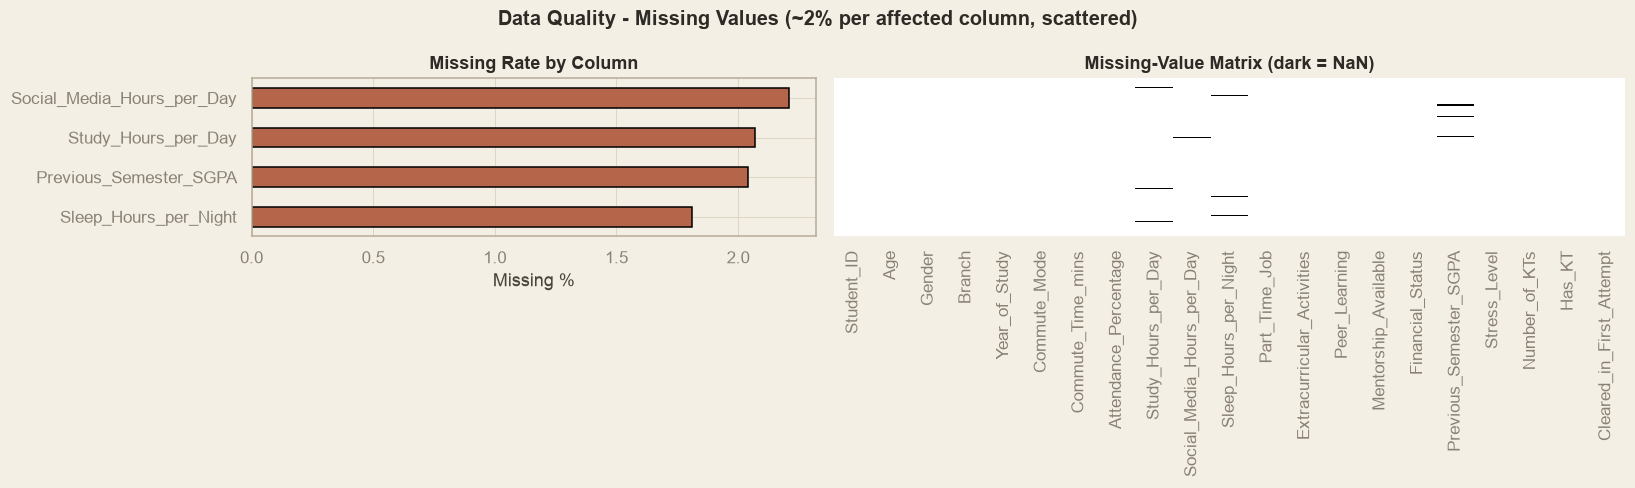

In [9]:
# 4.4 ภาพ missing-value matrix
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5), gridspec_kw={"width_ratios": [1, 1.4]})

missing["pct"].plot.barh(ax=axes[0], color=RUST, edgecolor="black")
axes[0].set_xlabel("Missing %")
axes[0].set_title("Missing Rate by Column")
axes[0].invert_yaxis()

sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="Greys",
            ax=axes[1])
axes[1].set_title("Missing-Value Matrix (dark = NaN)")
fig.suptitle("Data Quality - Missing Values (~2% per affected column, scattered)",
             fontsize=13, fontweight="bold")
fig.tight_layout()
save(fig, "01_missing_values.png")
plt.show()

## 5. ค่าสถิติเชิงพรรณนา (Descriptive Statistics)

### 5.1 ตัวแปรเชิงตัวเลข


In [10]:
df[NUMERIC].describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
Age,10000.0,21.018,2.022,18.00,19.00,21.00,23.00,24.00
Commute_Time_mins,10000.0,69.096,35.114,10.00,41.00,67.00,94.00,180.00
Attendance_Percentage,10000.0,69.189,14.638,20.00,59.00,69.00,79.00,100.00
Study_Hours_per_Day,9793.0,2.986,1.468,0.00,2.00,3.00,4.00,8.50
Social_Media_Hours_per_Day,9779.0,3.510,1.487,0.00,2.50,3.50,4.50,8.00
Sleep_Hours_per_Night,9819.0,6.524,1.192,3.00,5.70,6.50,7.30,10.00
Previous_Semester_SGPA,9796.0,5.525,0.861,2.32,4.94,5.52,6.11,9.08
Number_of_KTs,10000.0,1.535,1.330,0.00,0.00,1.00,2.00,7.00


In [11]:
# ตารางสรุปแบบขยาย: range, mode, IQR, CV, skewness, kurtosis
def summary_stats(frame, features):
    rows = []
    for c in features:
        s = frame[c].dropna()
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        rows.append({
            "feature": c,
            "n": int(s.size),
            "mean": round(s.mean(), 3),
            "std": round(s.std(), 3),
            "CV_%": round(s.std() / s.mean() * 100, 1),   # coefficient of variation
            "min": round(s.min(), 3),
            "median": round(s.median(), 3),
            "max": round(s.max(), 3),
            "range": round(s.max() - s.min(), 3),
            "mode": round(s.mode().iloc[0], 3),
            "IQR": round(q3 - q1, 3),
            "skew": round(s.skew(), 3),
            "kurtosis": round(s.kurtosis(), 3),
        })
    return pd.DataFrame(rows).set_index("feature")

summary_tbl = summary_stats(df, NUMERIC)
summary_tbl

,n,mean,std,CV_%,min,median,max,range,mode,IQR,skew,kurtosis
feature,,,,,,,,,,,,
Age,10000,21.018,2.022,9.6,18.00,21.00,24.00,6.00,24.00,4.00,-0.006,-1.277
Commute_Time_mins,10000,69.096,35.114,50.8,10.00,67.00,180.00,170.00,10.00,53.00,0.296,-0.543
Attendance_Percentage,10000,69.189,14.638,21.2,20.00,69.00,100.00,80.00,75.00,20.00,-0.125,-0.227
Study_Hours_per_Day,9793,2.986,1.468,49.2,0.00,3.00,8.50,8.50,2.90,2.00,0.105,-0.331
Social_Media_Hours_per_Day,9779,3.510,1.487,42.4,0.00,3.50,8.00,8.00,3.80,2.00,0.074,-0.226
Sleep_Hours_per_Night,9819,6.524,1.192,18.3,3.00,6.50,10.00,7.00,6.50,1.60,0.023,-0.126
Previous_Semester_SGPA,9796,5.525,0.861,15.6,2.32,5.52,9.08,6.76,5.59,1.17,0.016,-0.042
Number_of_KTs,10000,1.535,1.330,86.6,0.00,1.00,7.00,7.00,1.00,2.00,0.789,0.445


**อ่านตาราง**

- `skew` ใกล้ 0 เกือบทุกตัว → การแจกแจงค่อนข้างสมมาตร; `Number_of_KTs` เบ้ขวาเล็กน้อย (นับจำนวน)
- `kurtosis` ติดลบหลายตัว → หางบางกว่าปกติ (แจกแจงค่อนข้างแบน/uniform-ish) โดยเฉพาะ `Age`, `Commute_Time_mins`
- `CV_%` สูงสุดที่ `Number_of_KTs` และ `Commute_Time_mins` → กระจายตัวมากเมื่อเทียบกับค่าเฉลี่ย


In [12]:
# IQR-rule outliers (ทั้งชุดข้อมูล)
def iqr_outliers(frame, features):
    rows = []
    for c in features:
        s = frame[c].dropna()
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        iqr = q3 - q1
        lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        mask = (s < lo) | (s > hi)
        rows.append({"feature": c, "lower": round(lo, 2), "upper": round(hi, 2),
                     "n_outliers": int(mask.sum()),
                     "outlier_%": round(mask.mean() * 100, 2)})
    return pd.DataFrame(rows)

iqr_tbl = iqr_outliers(df, NUMERIC)
print(iqr_tbl.to_string(index=False))
print("\nรวม outlier:", int(iqr_tbl.n_outliers.sum()),
      "จุด — ส่วนใหญ่อยู่ที่ Number_of_KTs (นักศึกษ 5-7 KT ซึ่งพบน้อย)")

                   feature  lower  upper  n_outliers  outlier_%
                       Age  13.00  29.00           0       0.00
         Commute_Time_mins -38.50 173.50          20       0.20
     Attendance_Percentage  29.00 109.00          34       0.34
       Study_Hours_per_Day  -1.00   7.00          21       0.21
Social_Media_Hours_per_Day  -0.50   7.50          33       0.34
     Sleep_Hours_per_Night   3.30   9.70          66       0.67
    Previous_Semester_SGPA   3.19   7.86          50       0.51
             Number_of_KTs  -3.00   5.00          88       0.88

รวม outlier: 312 จุด — ส่วนใหญ่อยู่ที่ Number_of_KTs (นักศึกษ 5-7 KT ซึ่งพบน้อย)


### 5.2 ตัวแปรจัดกลุ่ม (Categorical) — ตารางความถี่

In [13]:
def freq_table(frame, col):
    vc = frame[col].value_counts(dropna=False)
    out = pd.DataFrame({"count": vc, "percent": (vc / len(frame) * 100).round(1)})
    if col in ORDER:
        out = out.reindex(ORDER[col])
    return out

for c in ["Gender", "Branch", "Year_of_Study", "Commute_Mode", "Financial_Status",
          "Stress_Level", "Part_Time_Job", "Peer_Learning", "Mentorship_Available",
          "Extracurricular_Activities", "Has_KT", "Cleared_in_First_Attempt"]:
    print(f"\n=== {c} ===")
    print(freq_table(df, c).to_string())


=== Gender ===
        count  percent
Gender                
Male     5902     59.0
Female   3921     39.2
Other     177      1.8

=== Branch ===
                                        count  percent
Branch                                                
Computer Engineering                     2522     25.2
Information Technology                   2043     20.4
Artificial Intelligence & Data Science   1508     15.1
Electronics & Telecom (EXTC)             1449     14.5
Civil Engineering                        1026     10.3
Mechanical Engineering                    971      9.7
Electrical Engineering                    481      4.8

=== Year_of_Study ===
               count  percent
Year_of_Study                
First Year      2449     24.5
Second Year     2488     24.9
Third Year      2564     25.6
Final Year      2499     25.0

=== Commute_Mode ===
              count  percent
Commute_Mode                
Local Train    5509     55.1
Bus            1952     19.5
Two-Wheeler    14

**อ่านตาราง**

- **Gender** ไม่สมดุล: Male ~59%, Female ~39%, Other ~2%
- **Branch** กระจุกที่ Computer Engineering + IT + AI&DS รวมกันเกิน 60%
- **Year_of_Study** สมดุลดี (~25% ต่อชั้นปี) — ออกแบบมาให้เท่ากัน
- **Commute_Mode**: กว่าครึ่ง (55%) ใช้ *Local Train* ซึ่งเป็นบริบทเฉพาะของมุมไบ
- **Stress_Level**: Low 50% · Medium 32% · High 18%
- **เป้าหมาย** `Has_KT = Yes` สูงถึง **74.1%** (ไม่สมดุล) — และเป็นส่วนเติมเต็มของ `Cleared_in_First_Attempt`


## 6. การแจกแจงตัวแปร (Univariate Visualization)

saved: charts/02_hist_numeric.png


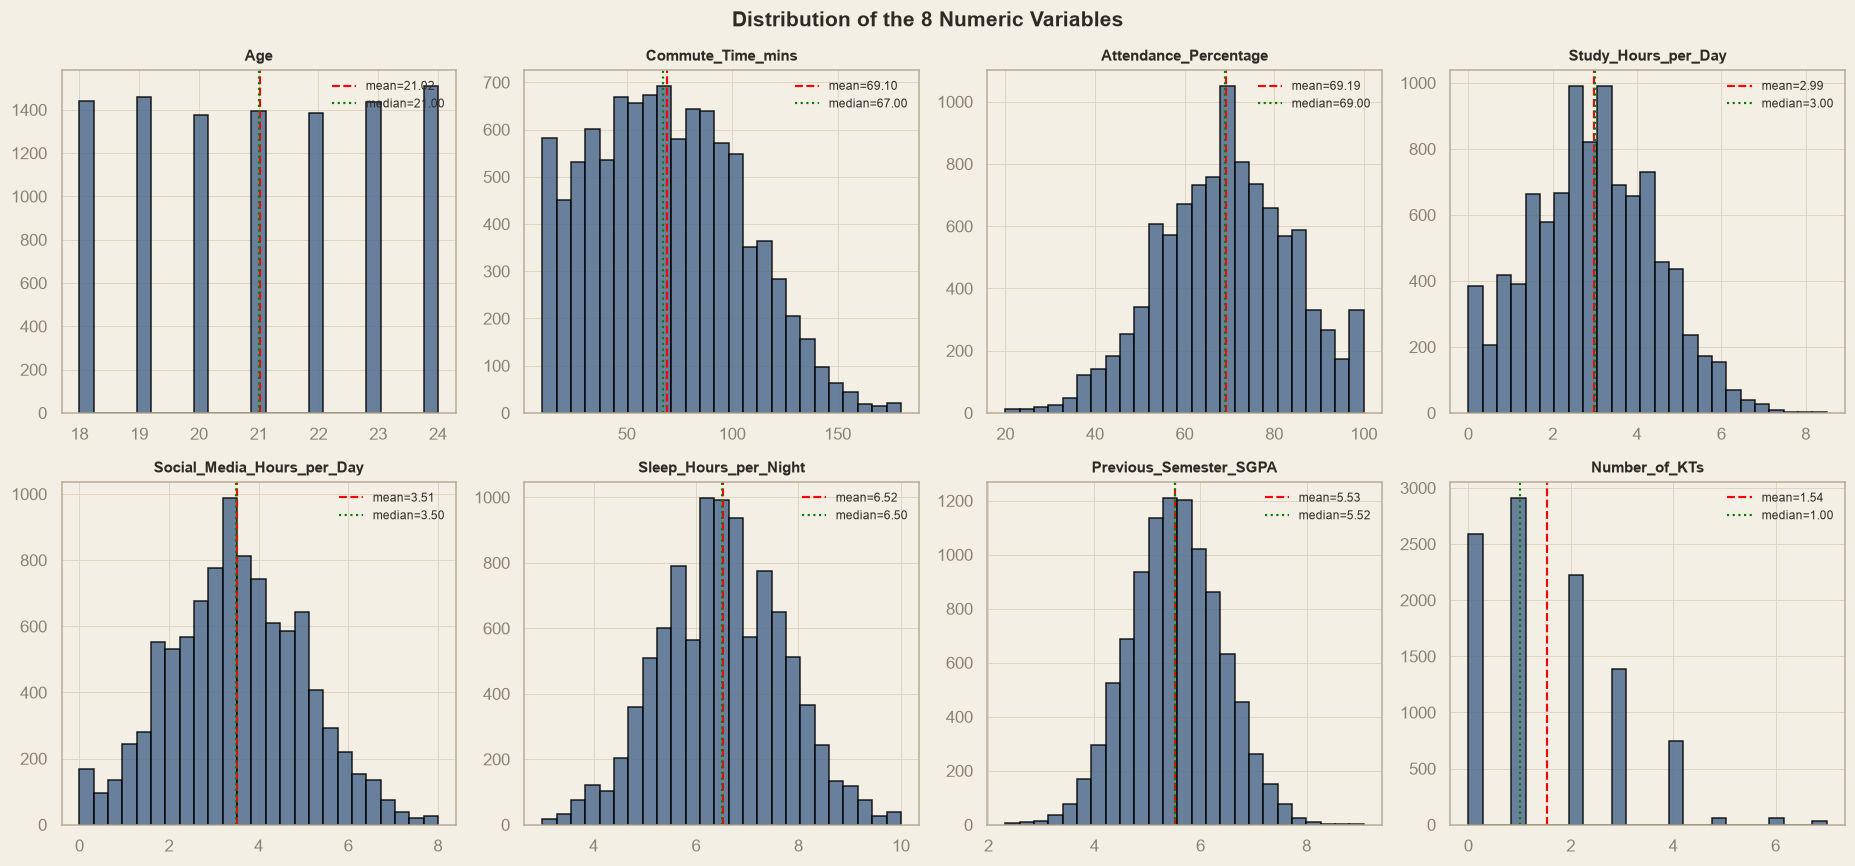

In [14]:
# 6.1 Histogram grid ของตัวแปรตัวเลขทั้ง 8
fig, axes = plt.subplots(2, 4, figsize=(17, 8))
for ax, c in zip(axes.flat, NUMERIC):
    data = df[c].dropna()
    ax.hist(data, bins=25, color=BLUE, edgecolor="black", alpha=0.85)
    ax.axvline(data.mean(), color="red", linestyle="--", linewidth=1.4,
               label=f"mean={data.mean():.2f}")
    ax.axvline(data.median(), color="green", linestyle=":", linewidth=1.4,
               label=f"median={data.median():.2f}")
    ax.set_title(c, fontsize=10)
    ax.legend(fontsize=8)
fig.suptitle("Distribution of the 8 Numeric Variables", fontsize=14, fontweight="bold")
fig.tight_layout()
save(fig, "02_hist_numeric.png")
plt.show()

saved: charts/03_bar_categorical.png


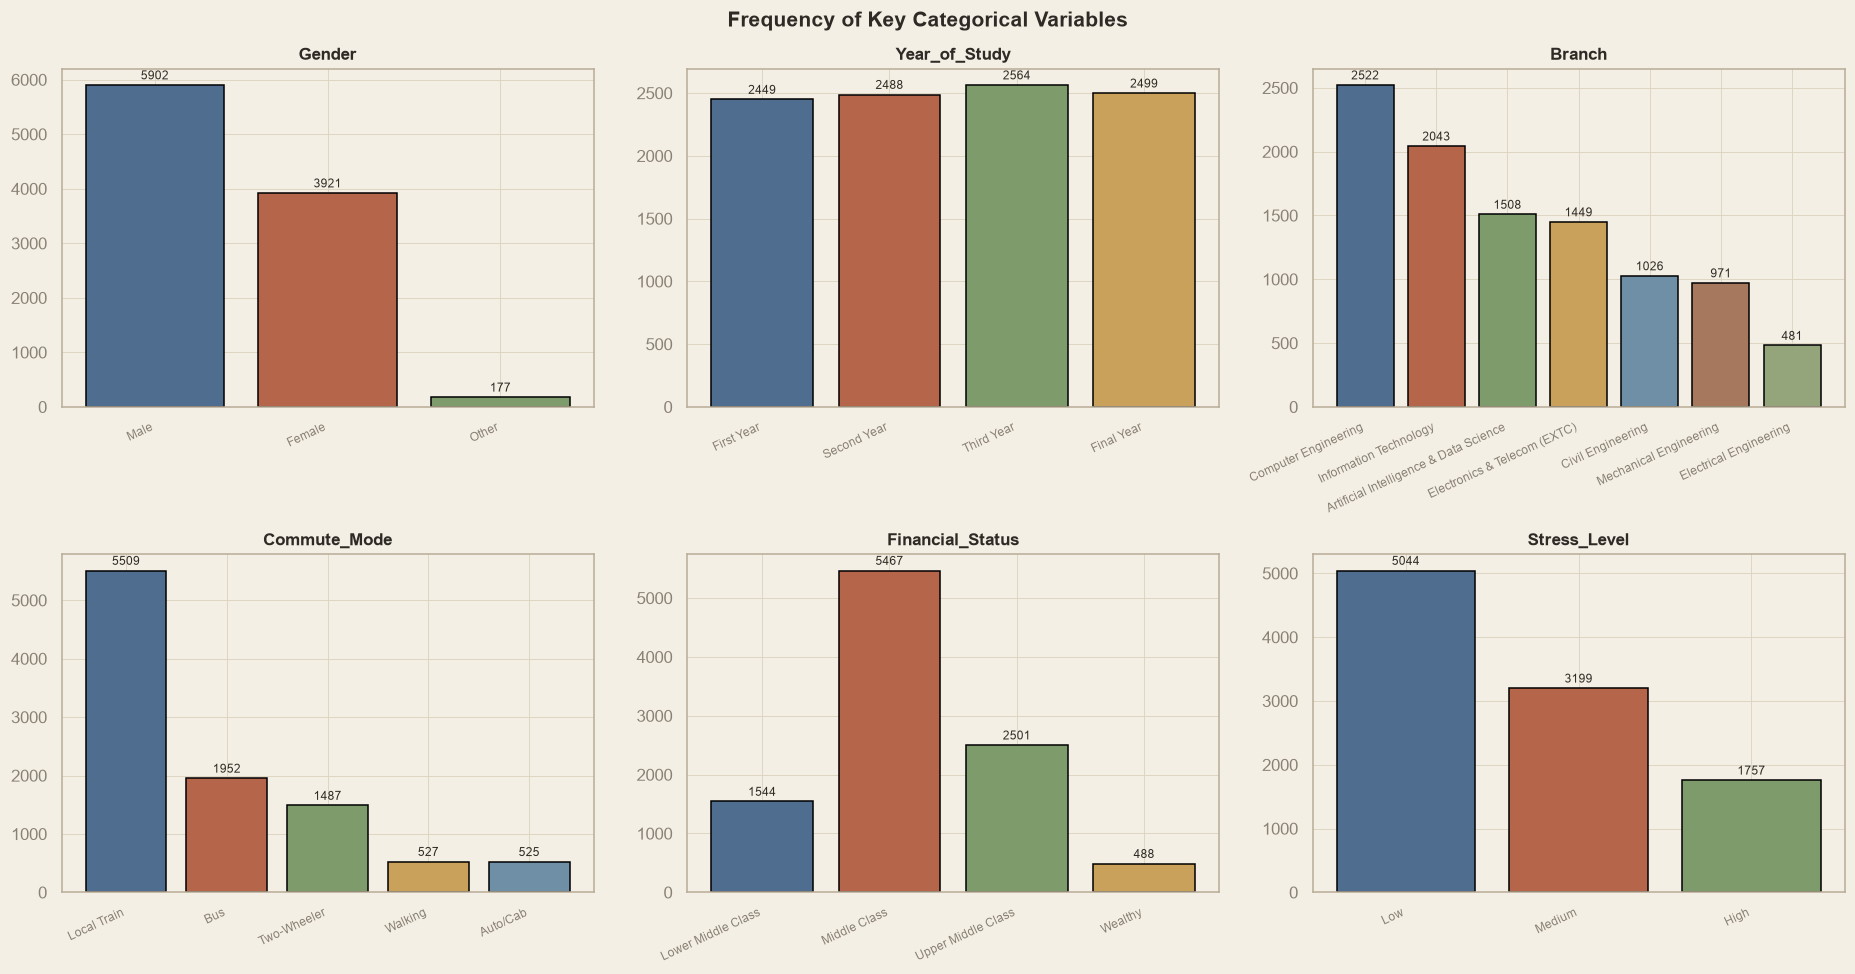

In [15]:
# 6.2 Bar charts ของตัวแปรจัดกลุ่มหลัก
cat_show = ["Gender", "Year_of_Study", "Branch", "Commute_Mode",
            "Financial_Status", "Stress_Level"]
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
for ax, c in zip(axes.flat, cat_show):
    vc = df[c].value_counts()
    if c in ORDER:
        vc = vc.reindex(ORDER[c])
    bars = ax.bar(range(len(vc)), vc.values, color=(PAL_EXT * 3)[:len(vc)],
                  edgecolor="black")
    ax.bar_label(bars, padding=2, fontsize=8)
    ax.set_xticks(range(len(vc)))
    ax.set_xticklabels(vc.index, rotation=25, ha="right", fontsize=8)
    ax.set_title(c, fontsize=11)
fig.suptitle("Frequency of Key Categorical Variables", fontsize=14, fontweight="bold")
fig.tight_layout()
save(fig, "03_bar_categorical.png")
plt.show()

saved: charts/04_target_distribution.png


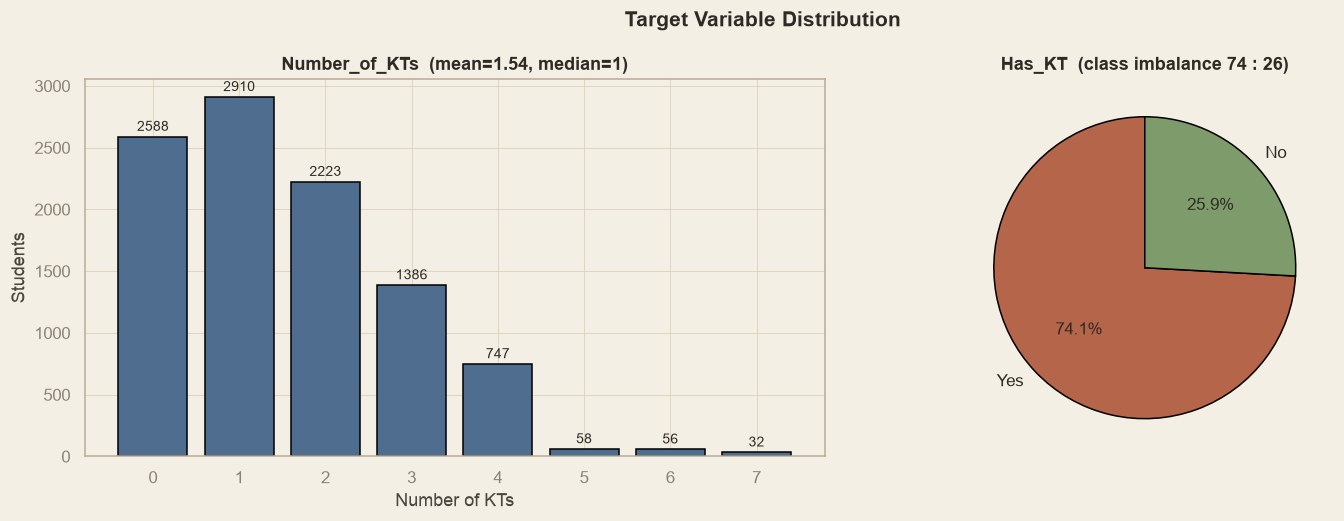

In [16]:
# 6.3 ตัวแปรเป้าหมาย: Number_of_KTs และ Has_KT
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

vc = df["Number_of_KTs"].value_counts().sort_index()
bars = axes[0].bar(vc.index, vc.values, color=BLUE, edgecolor="black")
axes[0].bar_label(bars, padding=2, fontsize=9)
axes[0].set_xlabel("Number of KTs"); axes[0].set_ylabel("Students")
axes[0].set_title(f"Number_of_KTs  (mean={df.Number_of_KTs.mean():.2f}, "
                  f"median={df.Number_of_KTs.median():.0f})")

hk = df["Has_KT"].value_counts()
axes[1].pie(hk.values, labels=hk.index, autopct="%1.1f%%", startangle=90,
            colors=[RUST, SAGE], wedgeprops=dict(edgecolor="black"))
axes[1].set_title("Has_KT  (class imbalance 74 : 26)")
fig.suptitle("Target Variable Distribution", fontsize=14, fontweight="bold")
fig.tight_layout()
save(fig, "04_target_distribution.png")
plt.show()

## 7. ความสัมพันธ์ระหว่างตัวแปร (Relationships)

แบ่งเป็น 3 คู่ประเภท:

| คู่ตัวแปร | เครื่องมือที่ใช้ |
|---|---|
| ตัวเลข ↔ ตัวเลข | Pearson & Spearman correlation, scatter/regression |
| ตัวเลข ↔ กลุ่ม | boxplot / violin, ค่าเฉลี่ยและมัธยฐานแยกกลุ่ม |
| กลุ่ม ↔ กลุ่ม | crosstab, stacked bar, **Cramér's V** (ค่าความสัมพันธ์) |


### 7.1 ตัวเลข ↔ ตัวเลข — Correlation heatmap

saved: charts/05_correlation_heatmap.png


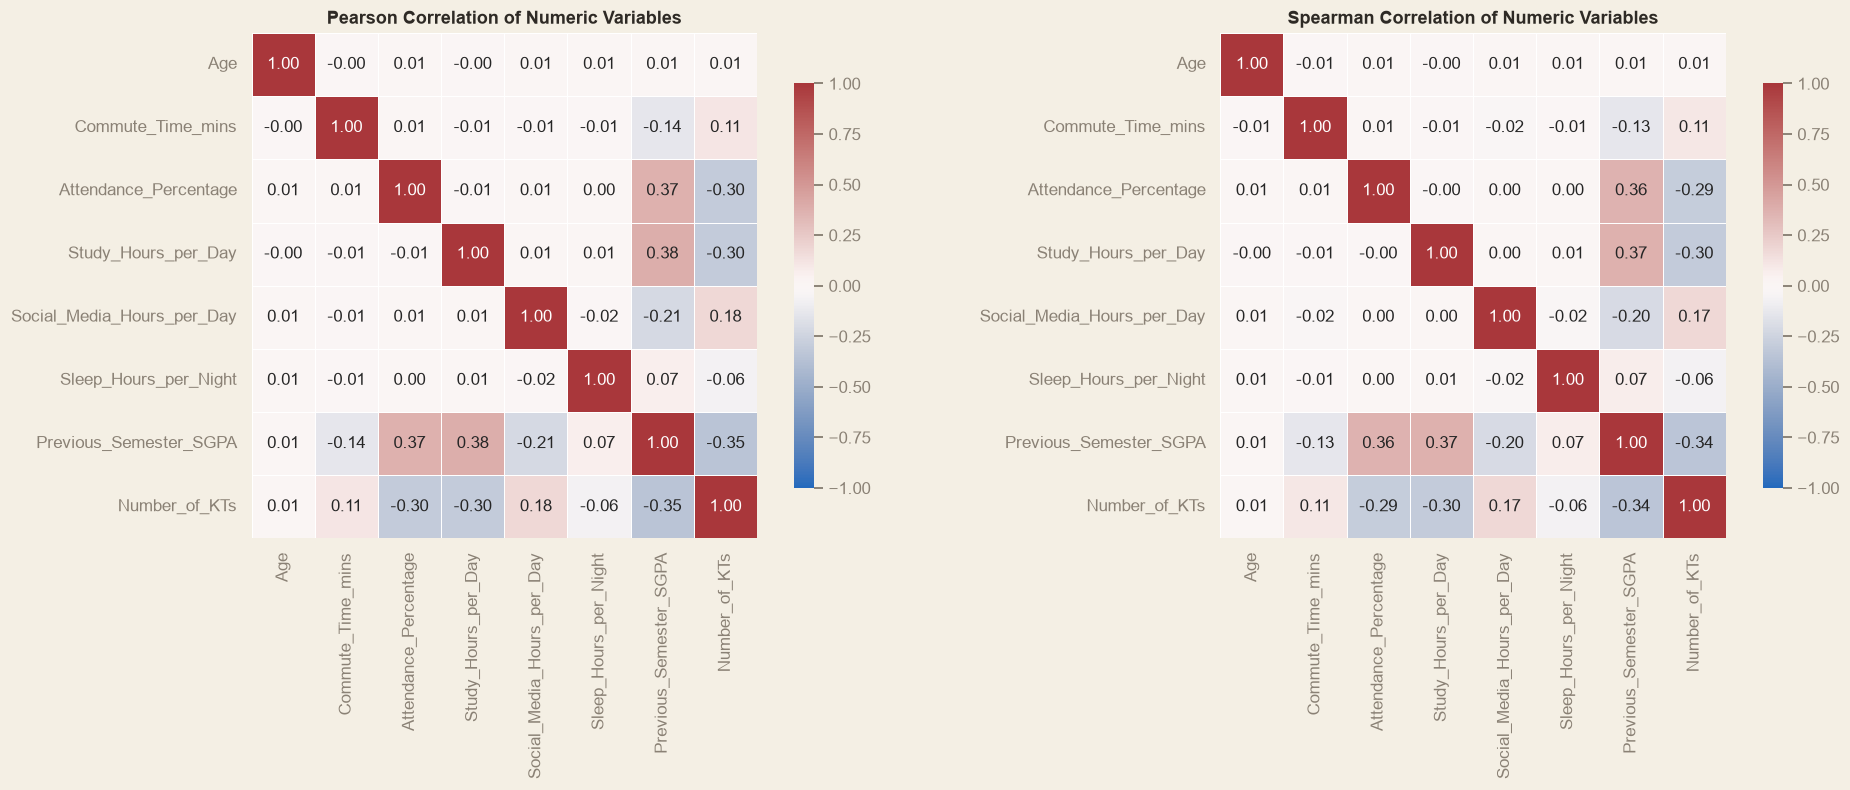

,Age,Commute_Time_mins,Attendance_Percentage,Study_Hours_per_Day,Social_Media_Hours_per_Day,Sleep_Hours_per_Night,Previous_Semester_SGPA,Number_of_KTs
Age,1.000,-0.004,0.008,-0.004,0.009,0.008,0.006,0.011
Commute_Time_mins,-0.004,1.000,0.011,-0.011,-0.014,-0.005,-0.139,0.115
Attendance_Percentage,0.008,0.011,1.000,-0.005,0.005,0.004,0.375,-0.302
Study_Hours_per_Day,-0.004,-0.011,-0.005,1.000,0.007,0.012,0.383,-0.304
Social_Media_Hours_per_Day,0.009,-0.014,0.005,0.007,1.000,-0.016,-0.213,0.177
Sleep_Hours_per_Night,0.008,-0.005,0.004,0.012,-0.016,1.000,0.069,-0.063
Previous_Semester_SGPA,0.006,-0.139,0.375,0.383,-0.213,0.069,1.000,-0.350
Number_of_KTs,0.011,0.115,-0.302,-0.304,0.177,-0.063,-0.350,1.000


In [17]:
corr_p = df[NUMERIC].corr(method="pearson")
corr_s = df[NUMERIC].corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, (mat, name) in zip(axes, [(corr_p, "Pearson"), (corr_s, "Spearman")]):
    sns.heatmap(mat, annot=True, fmt=".2f", cmap="vlag", center=0, vmin=-1, vmax=1,
                square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
    ax.set_title(f"{name} Correlation of Numeric Variables", fontsize=12, fontweight="bold")
fig.tight_layout()
save(fig, "05_correlation_heatmap.png")
plt.show()

corr_p.round(3)

**อ่าน heatmap**

- ปัจจัยที่สัมพันธ์ (เชิงลบ) กับ `Number_of_KTs` มากสุดคือ
  **`Previous_Semester_SGPA` (r ≈ −0.35)**, `Study_Hours_per_Day` (−0.30), `Attendance_Percentage` (−0.30)
- `Social_Media_Hours_per_Day` สัมพันธ์**บวก** (r ≈ +0.18) และ `Commute_Time_mins` (+0.11)
- `Sleep_Hours_per_Night` และ `Age` แทบไม่สัมพันธ์กับ KT
- ตัวแปรอินพุตด้วยกันเองสหสัมพันธ์ต่ำ → **ไม่มี multicollinearity** รุนแรง (ต่างจากชุด Wheat Seeds)
- Pearson กับ Spearman ให้ภาพใกล้เคียงกัน → ความสัมพันธ์เป็นเชิงเส้นเป็นหลัก ไม่ได้เกิดจาก outlier


saved: charts/06_numeric_vs_target.png


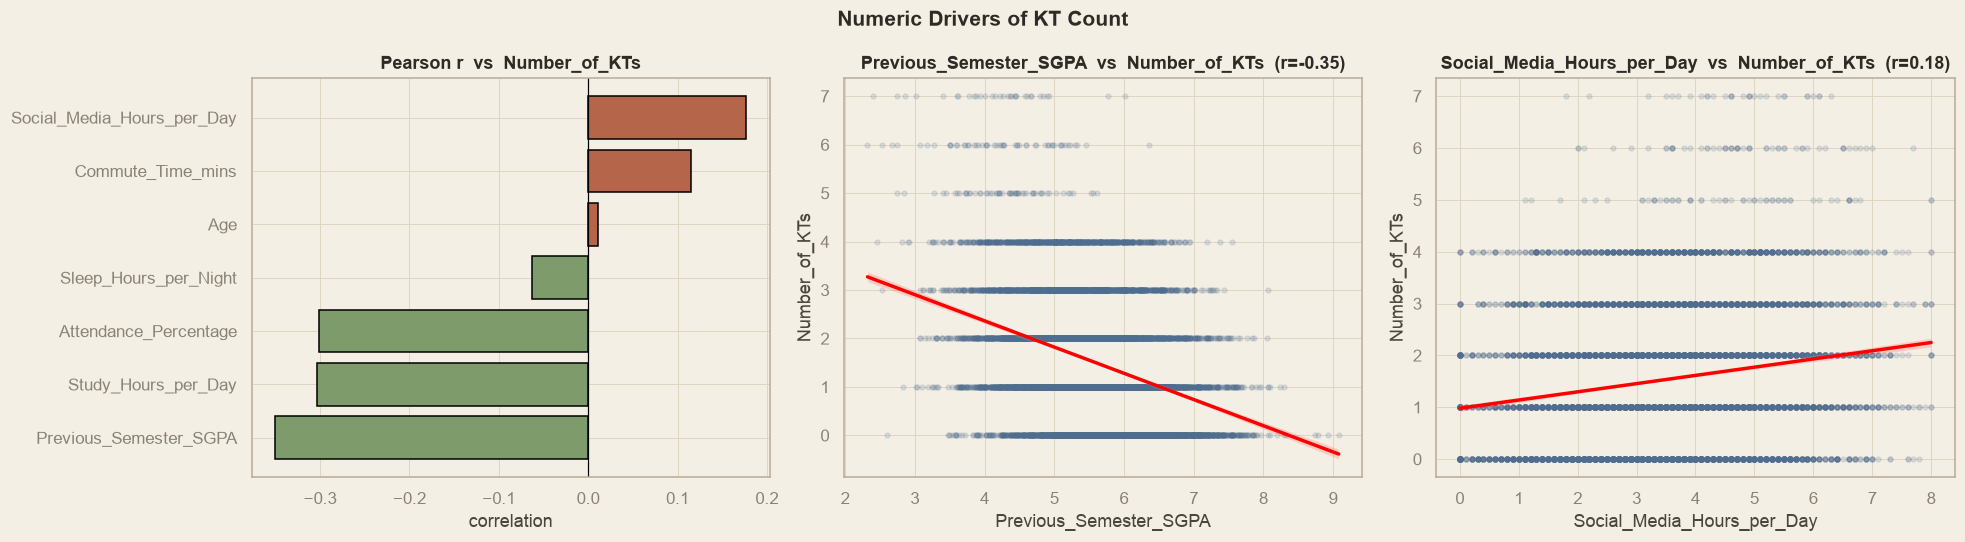

In [18]:
# 7.1b Bar สรุปสหสัมพันธ์กับเป้าหมาย + scatter คู่เด่น
corr_target = corr_p["Number_of_KTs"].drop("Number_of_KTs").sort_values()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = [SAGE if v < 0 else RUST for v in corr_target.values]
axes[0].barh(corr_target.index, corr_target.values, color=colors, edgecolor="black")
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_title("Pearson r  vs  Number_of_KTs")
axes[0].set_xlabel("correlation")

for ax, x in zip(axes[1:], ["Previous_Semester_SGPA", "Social_Media_Hours_per_Day"]):
    sns.regplot(data=df, x=x, y="Number_of_KTs", ax=ax,
                scatter_kws=dict(s=10, alpha=0.15, color=BLUE),
                line_kws=dict(color="red"))
    ax.set_title(f"{x}  vs  Number_of_KTs  (r={corr_p.loc[x,'Number_of_KTs']:.2f})")
fig.suptitle("Numeric Drivers of KT Count", fontsize=14, fontweight="bold")
fig.tight_layout()
save(fig, "06_numeric_vs_target.png")
plt.show()

### 7.2 ตัวเลข ↔ กลุ่ม — การกระจายของปัจจัยตัวเลขแยกตาม `Has_KT`

saved: charts/07_violin_by_haskt.png


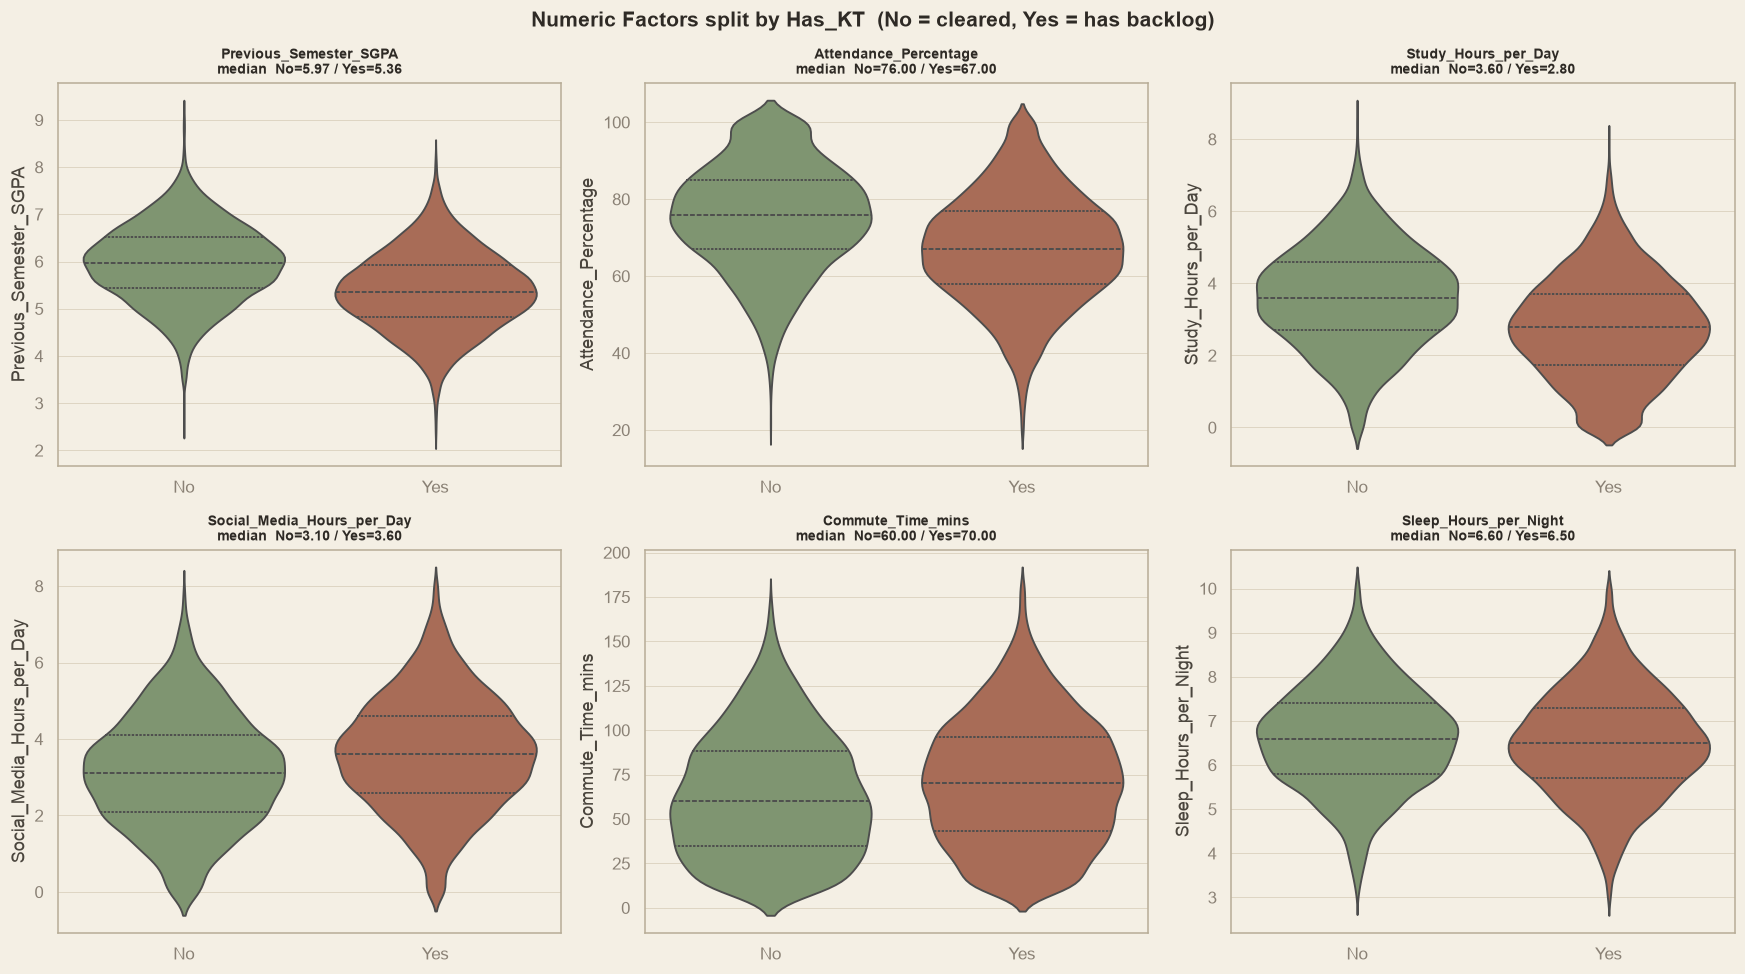

In [19]:
key_num = ["Previous_Semester_SGPA", "Attendance_Percentage",
           "Study_Hours_per_Day", "Social_Media_Hours_per_Day",
           "Commute_Time_mins", "Sleep_Hours_per_Night"]
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, c in zip(axes.flat, key_num):
    sns.violinplot(data=df, x="Has_KT", y=c, order=["No", "Yes"],
                   hue="Has_KT", palette={"No": SAGE, "Yes": RUST},
                   legend=False, inner="quartile", ax=ax)
    d = df.groupby("Has_KT")[c].median()
    ax.set_title(f"{c}\nmedian  No={d['No']:.2f} / Yes={d['Yes']:.2f}", fontsize=9)
    ax.set_xlabel("")
fig.suptitle("Numeric Factors split by Has_KT  (No = cleared, Yes = has backlog)",
             fontsize=14, fontweight="bold")
fig.tight_layout()
save(fig, "07_violin_by_haskt.png")
plt.show()

กลุ่ม `Has_KT = Yes` มี SGPA / การเข้าเรียน / ชั่วโมงอ่านหนังสือ **ต่ำกว่า**อย่างเห็นได้ชัด
และใช้โซเชียล / เวลาเดินทาง **มากกว่า** — สอดคล้องกับ heatmap


In [20]:
# 7.3 ค่าเฉลี่ย Number_of_KTs และ %Has_KT แยกตามตัวแปรกลุ่ม
group_cols = ["Stress_Level", "Commute_Mode", "Peer_Learning", "Mentorship_Available",
              "Part_Time_Job", "Extracurricular_Activities", "Financial_Status",
              "Gender", "Year_of_Study", "Branch"]
rows = []
for c in group_cols:
    g = df.groupby(c).agg(n=(ID_COL, "size"),
                          mean_KTs=("Number_of_KTs", "mean"),
                          pct_HasKT=("Has_KT", lambda s: (s == "Yes").mean() * 100))
    spread = g.mean_KTs.max() - g.mean_KTs.min()
    rows.append({"variable": c, "spread_mean_KTs": round(spread, 2),
                 "min_group_mean": round(g.mean_KTs.min(), 2),
                 "max_group_mean": round(g.mean_KTs.max(), 2)})
effect_tbl = pd.DataFrame(rows).sort_values("spread_mean_KTs", ascending=False)
print(effect_tbl.to_string(index=False))

                  variable  spread_mean_KTs  min_group_mean  max_group_mean
              Stress_Level             2.91            0.59            3.50
             Part_Time_Job             0.44            1.47            1.91
      Mentorship_Available             0.41            1.25            1.66
             Peer_Learning             0.37            1.39            1.76
              Commute_Mode             0.29            1.32            1.61
                    Gender             0.10            1.44            1.54
          Financial_Status             0.09            1.48            1.57
                    Branch             0.08            1.50            1.58
             Year_of_Study             0.06            1.51            1.57
Extracurricular_Activities             0.01            1.53            1.54


/var/folders/zh/_vkzx9qx0px53lxt3ztlwy7w0000gn/T/ipykernel_86955/2770663708.py:6: UserWarning: The palette list has more values (5) than needed (3), which may not be intended.
  sns.barplot(data=df, x=c, y="Number_of_KTs", order=order,


/var/folders/zh/_vkzx9qx0px53lxt3ztlwy7w0000gn/T/ipykernel_86955/2770663708.py:6: UserWarning: The palette list has more values (5) than needed (2), which may not be intended.
  sns.barplot(data=df, x=c, y="Number_of_KTs", order=order,
/var/folders/zh/_vkzx9qx0px53lxt3ztlwy7w0000gn/T/ipykernel_86955/2770663708.py:6: UserWarning: The palette list has more values (5) than needed (2), which may not be intended.
  sns.barplot(data=df, x=c, y="Number_of_KTs", order=order,


saved: charts/08_meanKT_by_category.png


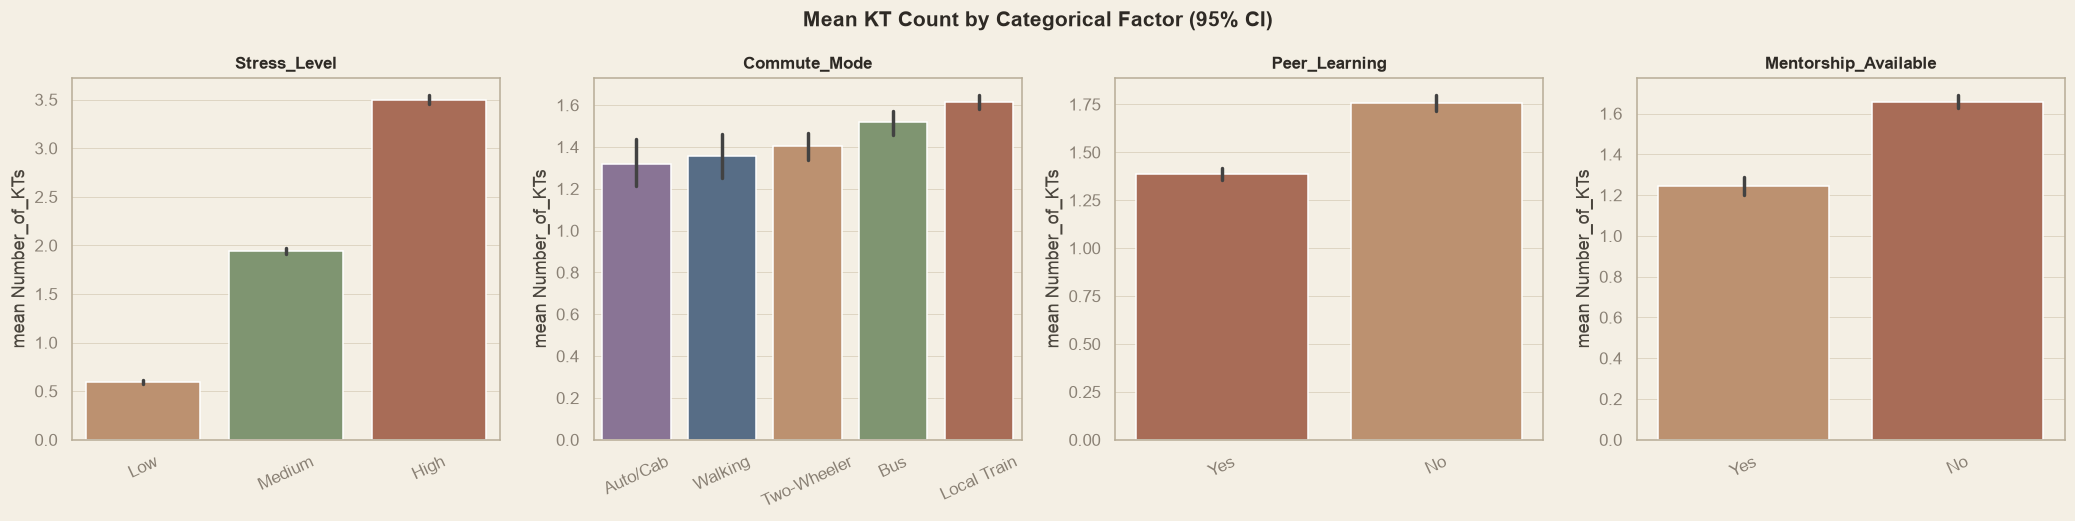

In [21]:
# 7.3b กราฟแท่ง: ตัวแปรกลุ่มที่ "แยก" จำนวน KT ได้ชัดที่สุด 4 ตัว
top_cat = ["Stress_Level", "Commute_Mode", "Peer_Learning", "Mentorship_Available"]
fig, axes = plt.subplots(1, 4, figsize=(19, 4.8))
for ax, c in zip(axes, top_cat):
    order = ORDER.get(c, df.groupby(c)["Number_of_KTs"].mean().sort_values().index.tolist())
    sns.barplot(data=df, x=c, y="Number_of_KTs", order=order,
                hue=c, palette=[RUST, "#C98F63", SAGE, BLUE, "#8A6E9B"], legend=False, errorbar=("ci", 95), ax=ax)
    ax.set_title(c, fontsize=11)
    ax.set_xlabel(""); ax.set_ylabel("mean Number_of_KTs")
    ax.tick_params(axis="x", rotation=25)
fig.suptitle("Mean KT Count by Categorical Factor (95% CI)", fontsize=14, fontweight="bold")
fig.tight_layout()
save(fig, "08_meanKT_by_category.png")
plt.show()

### 7.4 กลุ่ม ↔ กลุ่ม — Cramér's V

saved: charts/09_cramers_v.png


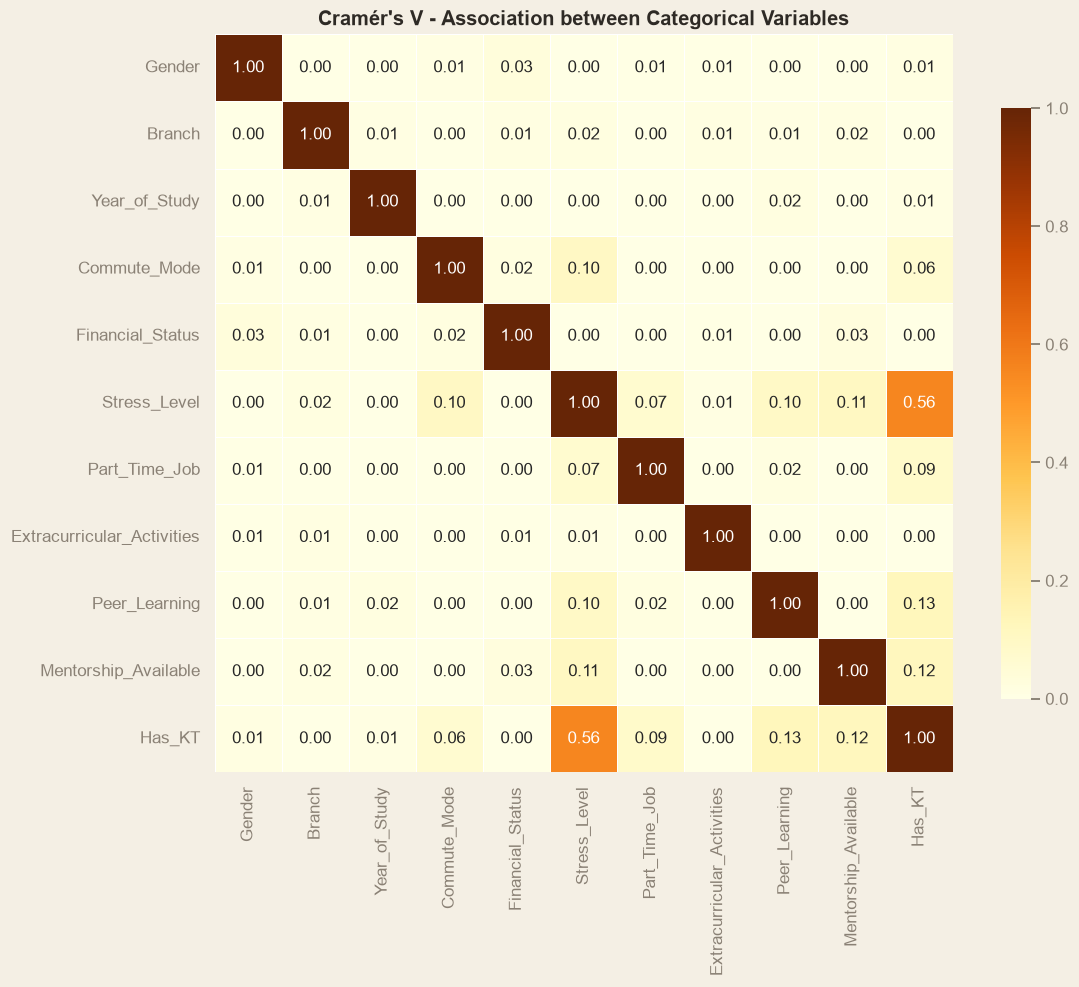

,Gender,Branch,Year_of_Study,Commute_Mode,Financial_Status,Stress_Level,Part_Time_Job,Extracurricular_Activities,Peer_Learning,Mentorship_Available,Has_KT
Gender,1.000,0.000,0.000,0.012,0.032,0.000,0.005,0.006,0.000,0.000,0.013
Branch,0.000,1.000,0.010,0.000,0.013,0.016,0.000,0.014,0.010,0.015,0.000
Year_of_Study,0.000,0.010,1.000,0.000,0.000,0.000,0.000,0.000,0.017,0.000,0.010
Commute_Mode,0.012,0.000,0.000,1.000,0.018,0.105,0.000,0.000,0.000,0.000,0.064
Financial_Status,0.032,0.013,0.000,0.018,1.000,0.000,0.000,0.007,0.000,0.027,0.000
Stress_Level,0.000,0.016,0.000,0.105,0.000,1.000,0.069,0.009,0.097,0.108,0.556
Part_Time_Job,0.005,0.000,0.000,0.000,0.000,0.069,1.000,0.000,0.018,0.000,0.086
Extracurricular_Activities,0.006,0.014,0.000,0.000,0.007,0.009,0.000,1.000,0.000,0.000,0.000
Peer_Learning,0.000,0.010,0.017,0.000,0.000,0.097,0.018,0.000,1.000,0.000,0.125
Mentorship_Available,0.000,0.015,0.000,0.000,0.027,0.108,0.000,0.000,0.000,1.000,0.118


In [22]:
def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct)[0]
    n = ct.to_numpy().sum()
    r, k = ct.shape
    phi2 = chi2 / n
    phi2c = max(0, phi2 - (k - 1) * (r - 1) / (n - 1))
    rc = r - (r - 1) ** 2 / (n - 1)
    kc = k - (k - 1) ** 2 / (n - 1)
    denom = min(kc - 1, rc - 1)
    return np.sqrt(phi2c / denom) if denom > 0 else np.nan

cat_for_v = ["Gender", "Branch", "Year_of_Study", "Commute_Mode", "Financial_Status",
             "Stress_Level", "Part_Time_Job", "Extracurricular_Activities",
             "Peer_Learning", "Mentorship_Available", "Has_KT"]
V = pd.DataFrame(index=cat_for_v, columns=cat_for_v, dtype=float)
for a in cat_for_v:
    for b in cat_for_v:
        V.loc[a, b] = 1.0 if a == b else cramers_v(df[a], df[b])

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(V.astype(float), annot=True, fmt=".2f", cmap="YlOrBr", vmin=0, vmax=1,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Cramér's V - Association between Categorical Variables",
             fontsize=13, fontweight="bold")
fig.tight_layout()
save(fig, "09_cramers_v.png")
plt.show()
V.astype(float).round(3)

**อ่าน Cramér's V**

- คู่ที่สัมพันธ์เด่นชัดคือ **`Stress_Level` ↔ `Has_KT`** — ค่าสูงมาก (นักศึกษาที่เครียด Medium/High เกือบทั้งหมดติด KT)
- ตัวแปรกลุ่มอื่น ๆ (เพศ สาขา ชั้นปี ฐานะ) แทบไม่สัมพันธ์กันเอง (V < 0.05) → ชุดข้อมูลออกแบบให้ demographic เป็นอิสระต่อกัน


saved: charts/10_stress_vs_haskt.png


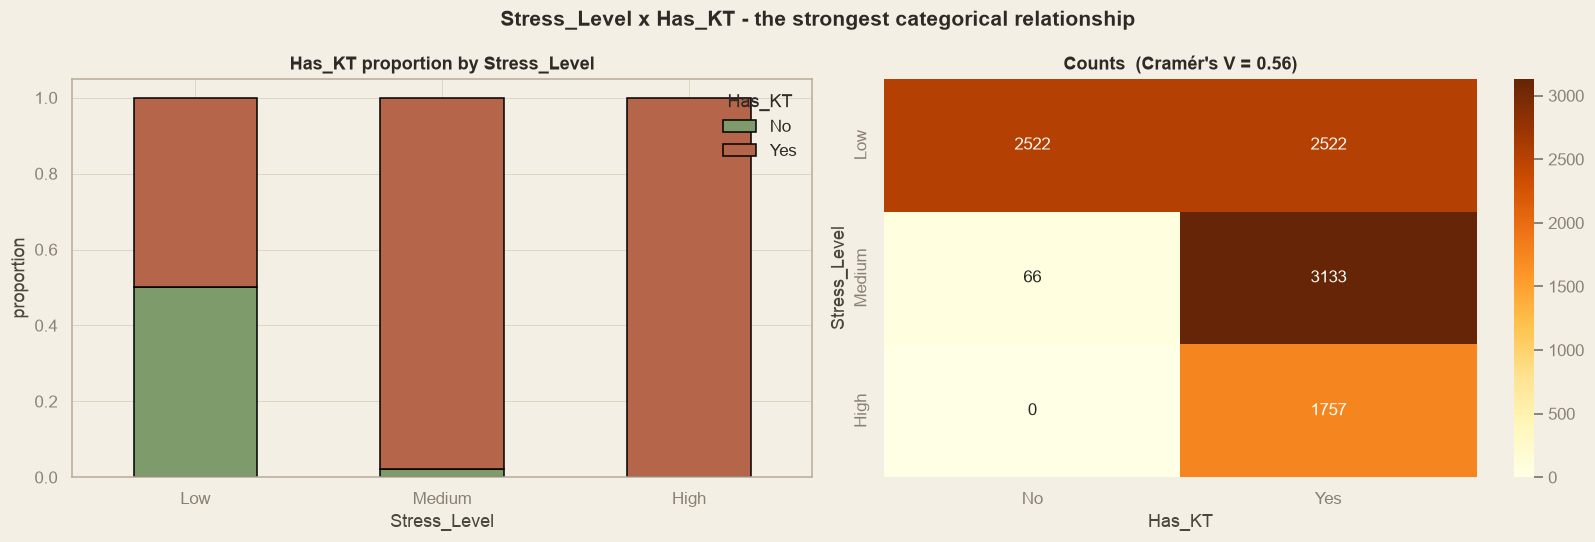

In [23]:
# 7.4b Stacked bar: สัดส่วน Has_KT แยกตาม Stress_Level
ct = pd.crosstab(df["Stress_Level"], df["Has_KT"], normalize="index").reindex(ORDER["Stress_Level"])
ct_cnt = pd.crosstab(df["Stress_Level"], df["Has_KT"]).reindex(ORDER["Stress_Level"])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
ct.plot(kind="bar", stacked=True, ax=axes[0],
        color={"No": SAGE, "Yes": RUST}, edgecolor="black")
axes[0].set_title("Has_KT proportion by Stress_Level")
axes[0].set_ylabel("proportion"); axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(title="Has_KT")

sns.heatmap(ct_cnt, annot=True, fmt="d", cmap="YlOrBr", ax=axes[1])
axes[1].set_title(f"Counts  (Cramér's V = {cramers_v(df.Stress_Level, df.Has_KT):.2f})")
fig.suptitle("Stress_Level x Has_KT - the strongest categorical relationship",
             fontsize=14, fontweight="bold")
fig.tight_layout()
save(fig, "10_stress_vs_haskt.png")
plt.show()

### 7.5 Pairplot ของปัจจัยตัวเลขหลัก แยกสีตาม `Has_KT`

saved: charts/11_pairplot.png


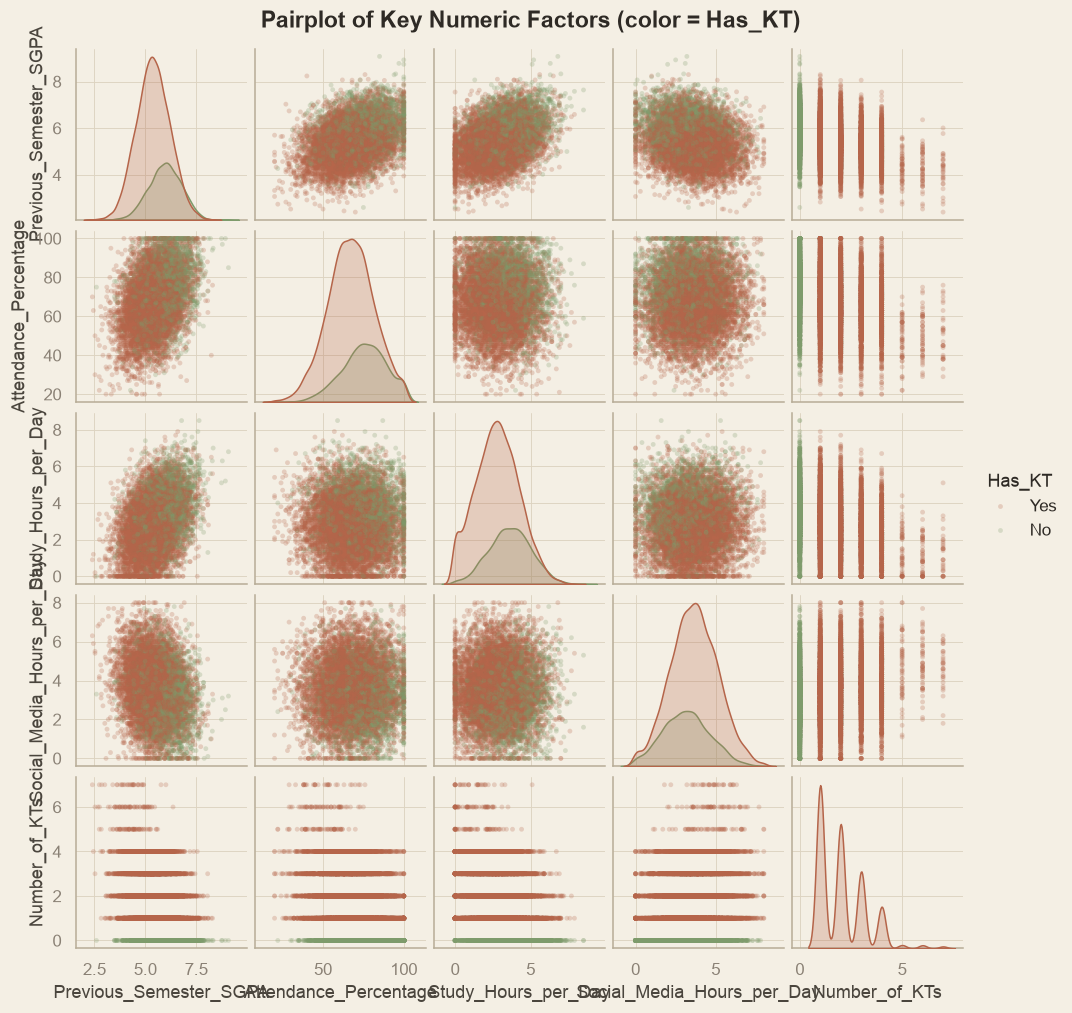

In [24]:
pair_cols = ["Previous_Semester_SGPA", "Attendance_Percentage",
             "Study_Hours_per_Day", "Social_Media_Hours_per_Day", "Number_of_KTs"]
g = sns.pairplot(df[pair_cols + ["Has_KT"]].dropna(), hue="Has_KT",
                 palette={"No": SAGE, "Yes": RUST},
                 diag_kind="kde", height=1.8, corner=False,
                 plot_kws=dict(s=10, alpha=0.25, edgecolor="none"))
g.fig.suptitle("Pairplot of Key Numeric Factors (color = Has_KT)",
               y=1.02, fontsize=15, fontweight="bold")
save(g.fig, "11_pairplot.png")
plt.show()

saved: charts/12_interaction_heatmap.png


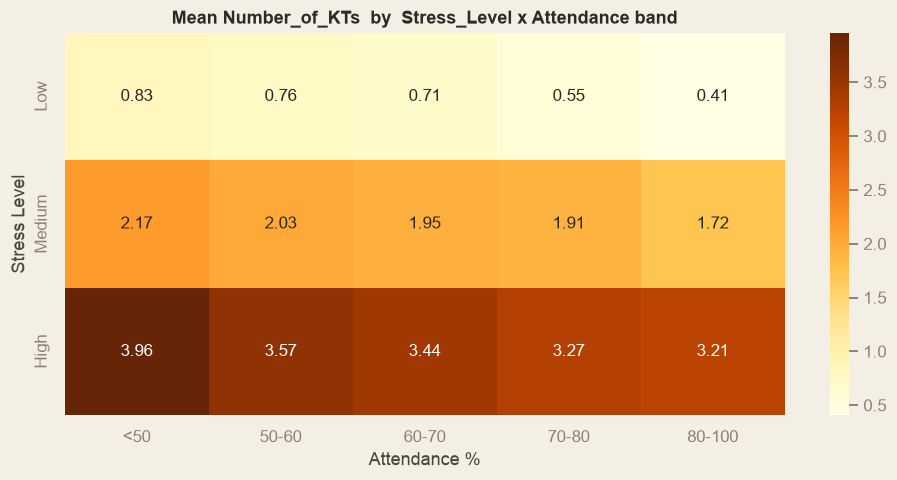

In [25]:
# 7.6 Heatmap: ค่าเฉลี่ย Number_of_KTs ตาม Stress_Level x Attendance band
df["_att_band"] = pd.cut(df["Attendance_Percentage"], [0, 50, 60, 70, 80, 100],
                         labels=["<50", "50-60", "60-70", "70-80", "80-100"])
piv = df.pivot_table(index="Stress_Level", columns="_att_band",
                     values="Number_of_KTs", aggfunc="mean", observed=True).reindex(ORDER["Stress_Level"])
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.heatmap(piv, annot=True, fmt=".2f", cmap="YlOrBr", ax=ax)
ax.set_title("Mean Number_of_KTs  by  Stress_Level x Attendance band",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Attendance %"); ax.set_ylabel("Stress Level")
fig.tight_layout()
save(fig, "12_interaction_heatmap.png")
plt.show()
df.drop(columns="_att_band", inplace=True)

## 8. สรุปข้อค้นพบ (Key Findings)

**โครงสร้าง & คุณภาพข้อมูล**

1. ข้อมูล 10,000 × 21 · ไม่มีแถวซ้ำ/รหัสซ้ำ · ค่าหายเฉพาะ 4 คอลัมน์ตัวเลข
   (`Study_Hours`, `Social_Media_Hours`, `Sleep_Hours`, `Previous_Semester_SGPA`) ประมาณ **2% ต่อคอลัมน์** กระจายแบบสุ่ม → เติมด้วย median/model ได้
2. **`Has_KT`, `Cleared_in_First_Attempt` และ `Number_of_KTs > 0` คือข้อมูลชุดเดียวกัน** — เลือกใช้ตัวเดียวเป็นเป้าหมาย

**สถิติเชิงพรรณนา**

3. ตัวแปรตัวเลขเกือบทั้งหมดแจกแจงสมมาตร (|skew| < 0.5) และค่อนข้างแบน (kurtosis ติดลบ) — คล้ายถูกสุ่มจาก uniform/normal
4. เป้าหมายไม่สมดุล: **74% ของนักศึกษาติด KT อย่างน้อย 1 วิชา**; ค่าเฉลี่ย 1.54 วิชา/คน, สูงสุด 7

**ความสัมพันธ์**

5. ปัจจัยเชิงบวกต่อผลการเรียน (ลด KT): **SGPA เดิม (r≈−0.35)**, ชั่วโมงอ่านหนังสือ (−0.30), การเข้าเรียน (−0.30)
6. ปัจจัยเชิงลบ (เพิ่ม KT): **ชั่วโมงโซเชียล (r≈+0.18)**, เวลาเดินทาง (+0.11); การนอนและอายุแทบไม่มีผล
7. ปัจจัยกลุ่มที่แยกความเสี่ยงได้ชัด: **`Stress_Level`** (Low 0.6 → High 3.5 วิชา), รองลงมา `Commute_Mode` (Local Train แย่สุด), `Peer_Learning`/`Mentorship_Available` (มี = ดีกว่าเล็กน้อย)
8. ปัจจัยที่ **ไม่มีผล**: เพศ, สาขา, ชั้นปี, ฐานะการเงิน, กิจกรรมนอกหลักสูตร
9. ตัวแปรอินพุตตัวเลขสหสัมพันธ์กันเองต่ำ → ไม่มี multicollinearity, ทุกตัวให้ข้อมูลเสริมกัน
10. เห็น interaction: นักศึกษาเครียดสูง + เข้าเรียนน้อย มีค่าเฉลี่ย KT แตะ ~4 วิชา — เป็นกลุ่มเป้าหมายของระบบ early-warning
